In [1]:
import pandas as pd
import numpy as np
import random
from datetime import date
import geopandas as gpd
import os

from PIL import Image
from matplotlib.patches import ConnectionPatch
from IPython.display import Image
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import matplotlib.patches as mpatches
from shapely.geometry import mapping
import matplotlib.colors as mcolors

import pygris
from pygris import tracts 
from pygris import block_groups 
from pygris import primary_secondary_roads
from pygris import school_districts
from pygris import counties 
from pygris.geocode import geocode

from census import Census
# Builing a Compartmetal Model

from sympy import Max,  parse_expr
from sympy import symbols, Matrix

from epymorph import *
from epymorph.compartment_model import *
from epymorph.engine.standard_sim import Output

# Runing the Simulation
from functools import partial

from epymorph.cli.run import save_csv

from epymorph.initializer import single_location
from epymorph.initializer import explicit

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from geopandas import GeoDataFrame, GeoSeries

# Building a geo 
from typing import cast

from epymorph import geo_library
from epymorph.geo.cache import load_from_cache, save_to_cache
from epymorph.geo.static import StaticGeo
from epymorph.data_shape import Shapes

from epymorph.geo.spec import AttribDef, CentroidDType, StaticGeoSpec, Year

/var/folders/_v/4q2_l88n1vndy51_ksbfylnc0000gn/T/ipykernel_28188/463157424.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.patches import Patch
import imageio
import os

In [31]:
STATE = 'AZ'
COUNTY = 'Maricopa'
YEAR = 2019
census_block_groups = block_groups(state = STATE, county = COUNTY, year = YEAR, cache=False)


Using FIPS code '04' for input 'AZ'
Using FIPS code '013' for input 'Maricopa'


# Movement GEO


In [68]:
geo_df = geo_library['maricopa_cbg_2019']().values
geo_df = pd.DataFrame({k: list(v) for k, v in geo_df.items()})

school_district = ['040134223021', '040134223042', '040134223053', '040134223072',
       '040138149002', '040138150003', '040138154001', '040134226411',
       '040134226412', '040134226422', '040134226431', '040134226432',
       '040134226441', '040138144002', '040134225092', '040134224011',
       '040138176001', '040134226061', '040134223082', '040134223083',
       '040134224021', '040134223093', '040134224033', '040138154003',
       '040134226171', '040134225093', '040134226213', '040134226222',
       '040134226231', '040134226232', '040138146001', '040134225072',
       '040134225103', '040134225112', '040134225122', '040134226062',
       '040134226063', '040134226173', '040134226201']
# Assuming geo_df and school_district are defined as per your initial setup
geo_df['population'] = geo_df['population_by_age'].apply(lambda x: x[0])

geo_df['population'] = geo_df.apply(lambda row: 0 if row['geoid'] not in school_district else row['population'], axis=1)

geo_df.head()

,average_household_size,centroid,geoid,label,median_age,median_income,pop_density_km2,population,population_by_age,population_by_age_x6,tract_gini_index,tract_median_income
0,2.33,"[-111.77075643330394, 33.76924660709943]",040130101011,040130101011,50.5,99219,99.319999,0,"[358, 1155, 278]","[358, 110, 671, 374, 194, 84]",0.4423,99489
1,2.15,"[-111.72000671148204, 33.7410933260103]",040130101012,040130101012,63.9,127614,68.782398,0,"[162, 883, 962]","[162, 0, 423, 460, 559, 403]",0.4423,99489
2,1.83,"[-111.66697569766907, 33.72404113568911]",040130101013,040130101013,70.8,80742,183.890869,0,"[0, 271, 993]","[0, 22, 0, 249, 655, 338]",0.4423,99489
3,2.04,"[-111.49136471795472, 33.71546544071483]",040130101021,040130101021,58.9,105987,0.480805,0,"[58, 775, 306]","[58, 52, 361, 362, 258, 48]",0.5439,134865
4,2.20,"[-111.8505100649063, 33.82609833466325]",040130101022,040130101022,62.8,128523,125.420289,0,"[110, 784, 593]","[110, 82, 202, 500, 452, 141]",0.5439,134865


In [71]:
geo_df['population'].max()

2095

In [14]:
CentroidDType = np.dtype([('longitude', np.float64), ('latitude', np.float64)])

In [5]:
dir_path = os.path.expanduser('~/Desktop/Github/EpiMoRPH-Modeling/social-determinate-of-health/scratch/Movement_model')
filename = 'matrix_array.npy'
file_path = os.path.join(dir_path, filename)

loaded_array = np.load(file_path)
loaded_array


array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0, 353]])

In [36]:
spec = StaticGeoSpec(
    attributes=[
        AttribDef('label', np.str_, Shapes.N),
        AttribDef('geoid', np.str_, Shapes.N),
        AttribDef('centroid', CentroidDType, Shapes.N),
        AttribDef('population', np.int64, Shapes.N),
        AttribDef('school_commuters', np.int64, Shapes.NxN),
    ],
    time_period=Year(2019))
spec

StaticGeoSpec(attributes=[AttribDef(name='label', dtype=<class 'numpy.str_'>, shape=Node()), AttribDef(name='geoid', dtype=<class 'numpy.str_'>, shape=Node()), AttribDef(name='centroid', dtype=dtype([('longitude', '<f8'), ('latitude', '<f8')]), shape=Node()), AttribDef(name='population', dtype=<class 'numpy.int64'>, shape=Node()), AttribDef(name='school_commuters', dtype=<class 'numpy.int64'>, shape=NodeAndNode())], time_period=Year(year=2019))

In [69]:
label = np.array(geo_df['label'], dtype=np.str_)
population = np.array(geo_df['population'], dtype=np.int64)
geoid = np.array(geo_df['geoid'], dtype=np.str_)
centroid = np.array(geo_df['centroid'], dtype=CentroidDType)
commuters = np.array(loaded_array, dtype=np.int64)

In [70]:
from epymorph.error import GeoValidationException
from epymorph.geo.static import StaticGeo

geo = StaticGeo(spec, {
    'label': label,
    'centroid': centroid,
    'geoid': geoid,
    'population': population,
    'school_commuters': commuters,
})

try:
    geo.validate()
except GeoValidationException as e:
    print(e.pretty())

In [39]:
from pathlib import Path

from epymorph.geo.static import StaticGeoFileOps

filename = StaticGeoFileOps.to_archive_filename('movement_geo')
filepath = Path('epymorph/data/geo') / filename

geo.save(filepath)

# Simulation


In [78]:
mm_library

OrderedDict([('centroids',
              <function epymorph.data.registry._mm_spec_loader.<locals>.load() -> epymorph.movement.parser.MovementSpec>),
             ('icecube',
              <function epymorph.data.registry._mm_spec_loader.<locals>.load() -> epymorph.movement.parser.MovementSpec>),
             ('no',
              <function epymorph.data.registry._mm_spec_loader.<locals>.load() -> epymorph.movement.parser.MovementSpec>),
             ('pei',
              <function epymorph.data.registry._mm_spec_loader.<locals>.load() -> epymorph.movement.parser.MovementSpec>),
             ('school',
              <function epymorph.data.registry._mm_spec_loader.<locals>.load() -> epymorph.movement.parser.MovementSpec>),
             ('sparsemod',
              <function epymorph.data.registry._mm_spec_loader.<locals>.load() -> epymorph.movement.parser.MovementSpec>)])

Running simulation (StandardSimulation):
• 2019-07-20 to 2019-08-20 (31 days)
• 2494 geo nodes
|####################| 100% 
Runtime: 89.685s


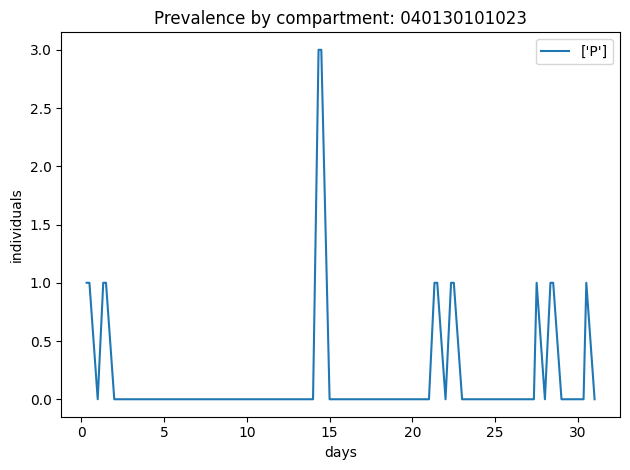

In [128]:
days = 31
sim = StandardSimulation(
        geo =  geo_library['movement_geo'](),
        ipm = ipm_library['no'](),
        mm = mm_library['school'](),
        params={
            'phi': 10,
            'phi_weekend': 20,
            'move_control': 0.1,
            'theta': 0.2
        },
        time_frame=TimeFrame.of("2019-07-20", days),
        initializer=partial(single_location, location=0, seed_size=0)
    )

with sim_messaging(sim):
    output = sim.run()
plot_pop(output, pop_idx=5)

single_simulation_out = '/Users/alexandernez/Desktop/Github/Epymorph_vignettes/scratch/Simulation_runs/movement_geo.csv'
save_csv(path=single_simulation_out, out = output )

In [129]:
model_data = pd.read_csv(single_simulation_out, low_memory=False)
labels = pd.DataFrame(geo_df['label'])

model_column = 'c0'
infected_rate_model_data = model_data[[model_column]]

result_df = []
nodes = 2494

# Create an empty DataFrame to hold the results
model_df = pd.DataFrame()

# Loop to create new DataFrames and concatenate them
for i in range(days * 3):
    start_idx = i * nodes
    end_idx = (i + 1) * nodes
    result_group = infected_rate_model_data[model_column].iloc[start_idx:end_idx].reset_index(drop=True)
    column_name = f"day {i + 1}"  # Compute column header based on the iteration
    result_group.rename(column_name, inplace=True)
    model_df = pd.concat([model_df, result_group], axis=1)

# Combine every two columns together
combined_df = pd.DataFrame()
for i in range(0, model_df.shape[1], 2):
    combined_column = model_df.iloc[:, i:i+3].sum(axis=1)
    combined_df[f"day {i//3 + 1}"] = combined_column

combined_df_labels = pd.concat([labels, model_df], axis=1)
combined_df_labels

,label,day 1,day 2,day 3,day 4,day 5,day 6,day 7,day 8,day 9,...,day 84,day 85,day 86,day 87,day 88,day 89,day 90,day 91,day 92,day 93
0,040130101011,10,10,0,0,0,0,0,0,0,...,0,7,7,0,0,0,0,0,0,0
1,040130101012,2,2,0,1,1,0,0,0,0,...,0,3,3,0,1,1,0,0,0,0
2,040130101013,2,2,0,0,0,0,0,0,0,...,0,3,3,0,3,3,0,0,0,0
3,040130101021,0,0,0,0,0,0,0,1,0,...,0,2,2,0,7,7,0,0,1,0
4,040130101022,4,4,0,0,0,0,0,0,0,...,0,0,0,0,3,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2489,040139413001,3,3,0,10,10,0,3,0,0,...,0,4,4,0,3,3,0,0,1,0
2490,040139413002,5,5,0,2,2,0,0,0,0,...,0,6,6,0,2,2,0,0,0,0
2491,040139413003,1,1,0,7,7,0,0,1,0,...,0,5,5,0,5,5,0,0,0,0
2492,040139413004,3,3,0,9,9,0,7,0,0,...,0,3,3,0,3,3,0,6,0,0


In [120]:
model_data

,t,p,c0
0,0,0,1
1,0,1,0
2,0,2,1
3,0,3,0
4,0,4,0
...,...,...,...
154623,61,2489,0
154624,61,2490,0
154625,61,2491,0
154626,61,2492,0


In [94]:
# Assuming combined_df_labels is your DataFrame and it includes a 'label' column

# Select columns to scale (excluding the 'label' column if it exists)
columns_to_scale = combined_df_labels.columns.difference(['label'])

# Apply Min-Max scaling
for col in columns_to_scale:
    min_col = combined_df_labels[col].min()
    max_col = combined_df_labels[col].max()
    combined_df_labels[col] = (combined_df_labels[col] - min_col) / (max_col - min_col)

# Now combined_df_labels contains the scaled data alongside the unchanged 'label' column
combined_df_labels.head()



,label,day 1,day 2,day 3,day 4,day 5,day 6,day 7,day 8,day 9,day 10,day 11
0,040130101011,0.000432,0.000216,0.000000,0.000144,0.000000,0.000072,0.000360,0.000360,0.000144,0.000144,0.000000
1,040130101012,0.000216,0.000000,0.000504,0.000432,0.000360,0.000360,0.000072,0.000000,0.000000,0.000000,0.000000
2,040130101013,0.000144,0.000144,0.000648,0.000576,0.000072,0.000072,0.000144,0.000360,0.000360,0.000360,0.000000
3,040130101021,0.000144,0.000000,0.000360,0.000432,0.000216,0.000648,0.000072,0.000288,0.000144,0.000144,0.000000
4,040130101022,0.000216,0.000072,0.000000,0.000144,0.000144,0.000072,0.000000,0.000000,0.000000,0.000144,0.000447


In [86]:
day_columns = [f'day {i}' for i in range(1, 31)]  # Create a list of day column names


In [87]:
max_value = combined_df_labels[day_columns].max().max()  # This selects only the "day" columns for the max calculation

max_value

4951

In [130]:

merged_df = pd.merge(census_block_groups, combined_df_labels, left_on='GEOID', right_on='label', how='inner')

gpd_df = gpd.GeoDataFrame(merged_df)

In [131]:
gpd_df

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,...,day 84,day 85,day 86,day 87,day 88,day 89,day 90,day 91,day 92,day 93
0,04,013,421702,3,040134217023,Block Group 3,G5030,S,310375,0,...,0,2,2,0,6,6,0,2,0,0
1,04,013,040531,2,040130405312,Block Group 2,G5030,S,616061,0,...,0,2,2,0,0,0,0,0,0,0
2,04,013,092312,1,040130923121,Block Group 1,G5030,S,295623,0,...,0,1,1,0,1,1,0,0,0,0
3,04,013,092721,1,040130927211,Block Group 1,G5030,S,1108648,0,...,0,0,0,0,2,2,0,0,0,0
4,04,013,093104,1,040130931041,Block Group 1,G5030,S,168697,0,...,0,2,2,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2489,04,013,811900,2,040138119002,Block Group 2,G5030,S,771839,0,...,0,5,5,0,5,5,0,0,0,0
2490,04,013,812000,1,040138120001,Block Group 1,G5030,S,1279036,0,...,0,3,3,0,9,9,0,0,0,0
2491,04,013,812000,2,040138120002,Block Group 2,G5030,S,1360898,0,...,0,4,4,0,7,7,0,0,0,0
2492,04,013,523002,3,040135230023,Block Group 3,G5030,S,666349,0,...,0,4,4,0,7,7,0,0,1,0


In [132]:
from PIL import Image
import os
import matplotlib.pyplot as plt
import geopandas as gpd

dpi = 300
columns_to_animate = ['day ' + str(day) for day in range(1, 93)]

# Create a list to store frames
frames = []

# Temporary directory to store image files
temp_dir = 'temp_images'
os.makedirs(temp_dir, exist_ok=True)

# Loop through the columns and create a frame for each day

ids = 0
for column in columns_to_animate:
    
    fig, (ax1) = plt.subplots(1, 1, figsize=(20, 10), dpi=dpi)

    census_block_groups.plot(ax = ax1, color='gray')
    gpd_df.plot(column=column, cmap='viridis', vmin = 0, 
        vmax = 30,linewidth = 0.1,  edgecolor='black', ax=ax1)
    
    ax1.set_title(f'Movers on tau tick {column[4:]}')  # Set the title for each frame
    ax1.axis('off')  
    
    # Save the frame as an image in the temporary directory
    img_file = os.path.join(temp_dir, f'day_{column[4:]}.png')
    plt.savefig(img_file, dpi=dpi, bbox_inches='tight')
    plt.close(fig)

    # Open and append the image to the frames list
    frames.append(Image.open(img_file))

# Save frames as a GIF
gif_filename = 'Movers.gif'
frames[0].save(
    gif_filename,
    save_all=True,
    append_images=frames[1:],
    duration=400,  # Time between frames in milliseconds
    loop=0  # 0 means infinite loop
)

# Clean up temporary image files
for img_file in os.listdir(temp_dir):
    file_path = os.path.join(temp_dir, img_file)
    os.remove(file_path)

# Remove the temporary directory
os.rmdir(temp_dir)

print(f'GIF saved as {gif_filename}')

GIF saved as Movers.gif
